# Método do Gradiente Descendente

Esta atividade apresenta de forma simples como funciona o método do gradiente descendente para a minimização de uma função custo.

Adaptado de Robert R. F. De Filippi.

## Função Custo

Em problemas de otimização, funções custo são utilizadas para quantificar a relação entre uma função e um valor associado, o qual, representa o custo. Uma função custo, ou funcional, é uma generalização do conceito de função: enquanto uma função relaciona dois valores, seja por meio de uma função simples como $y=x^2$, um funcional relaciona um valor a uma função. Um exemplo pode ser dado pela regressão linear, em que deseja-se minimizar o erro quadrático ao se ajustar determinados dados a uma curva reta (uma função). De outra forma, podemos maximizar uma função custo quando queremos encontrar a máxima verossimilhança entre dois eventos. Independente da motivação, a verificação da minimização ou da maximização de uma função custo, nos leva a enxergar determinadas propriedades dos nossos dados e eventos.

Podemos considerar, por simplicidade, uma função contínua de uma ou mais variáveis, contínua e de domínio real. Se a sua primeira derivada (em relação a uma ou mais variáveis) é conhecida, então podemos considerar esta derivada como uma função custo. O que obtemos quando temos a primeira devrivada e a igualamos a zero?

__Exemplo:__ Seja a função real $f(x) = y = x^{2}+5x-20$. A derivada primeira de $f(x)$ é dada por:

\begin{align}
\frac{dy}{dx} = 2x + 5
\end{align}

Fazendo $\frac{dy}{dx}=0$, obtemos:

\begin{align}
2x + 5 &= 0 \\
2x &= -5 \\
x &= \frac{-5}{2} = -2,5
\end{align}

Substituindo $x = \frac{-5}{2}$ na função original, obtemos $y = -26,25$.

Logo, os valores de $x=-2,5$ e $y=-26,25$ encontrados, são as coordenadas do vértice da parábola definida pela função original, ou seja, o mínimo dessa função.

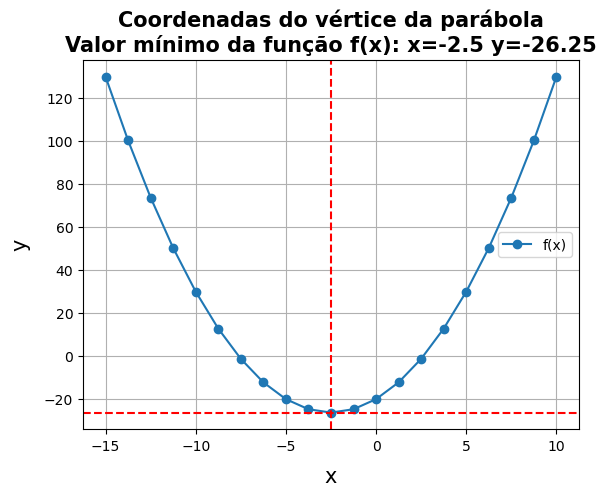

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-15,10,21)

yfunc = []
for xval in x:
    yval = np.power(xval,2) + 5*xval -20
    yfunc.append(yval)

# Mínimos de uma função quadrática
# minx = -b / 2*a
# miny = -delta / 4*a
minx = -5 / (2 * 1)
miny = -(np.power(-5,2) -4 * 1 * (-20)) / (4 * 1)
    
plt.plot(x,yfunc, linewidth=1.5, marker="o", label="f(x)")
plt.grid()
plt.axvline(minx, color="red", linewidth=1.5, ls="dashed")
plt.axhline(miny, color="red", linewidth=1.5, ls="dashed")
#plt.title("$y = x^{2} + 5x - 20$", fontweight="bold", size=15)
plt.title("Coordenadas do vértice da parábola\nValor mínimo da função f(x): x=" + str(minx) + " y=" + str(miny), fontweight="bold", size=15)
plt.xlabel("x", labelpad=10, size="15")
plt.ylabel("y", labelpad=10, size="15")
plt.legend()

plt.show()

## Método do Gradiente Descendente

Abaixo, iremos implementar o método do gradiente descendente para criar um processo de aprendizado com feedback. A cada passo de tempo, recebemos algumas informações novas, fazemos algumas atualizações em nossas estimativas que devem se mover em direção a uma combinação ótima de parâmetros. Vamos obter estas estimativas usando a função custo. Além disso, nosso algorítmo iterativo se adapta a cada iteração porque ele utiliza as informações do passo anterior.

Neste exemplo, vamos utilizar uma função quadrática simples, de apenas uma variável. Queremos encontrar o mínimo da função, e embora já saibamos fazer isso, vamos fazer de forma que possamos estender a idéia principal do algorítmo para funções de maior complexidade.

### Encontrando o Mínimo de uma Função Simples

Vamos fazer algo semelhante ao que já foi mostrado no início deste notebook. Seja a função $y = x^2 - 4x + 2$. Vamos calcular a sua derivada primeira e igualar o resultado a zero:

\begin{align}
y = f(x) &= x^2 - 4x + 2 \\
\frac{dy}{dx} &= 2x - 4 = 0 \\
x &= 2
\end{align}

Sendo uma função quadrática, podemos estudá-la e determinar se a concavidade da curva está apontada para cima ou para baixo, além de calcular as coordenadas do vértice da parábola que esta função descreve. Como podemos encontrar este resultado utilizando o Método do Gradiente Descendente?

Vamos dividir o problema matematicamente, pois precisaremos estimar um parâmetro que chamaremos de $\theta$, que será o nosso substituto para a variável $x$. $\theta$ é o valor que iremos atualizar a cada iteração e que irá nos dizer qual é o valor atual de $x$ ao longo do processo de minimização. $\theta$ deverá convergir para o valor mínimo da função custo.

Entretanto, nós não sabemos ainda qual o valor inicial de $\theta$. Então precisaremos dar um chute inicial. $\theta$ irá começar com este chute inicial em algum ponto ao longo da função custo e que irá descer em direção ao valor real. É isto que significa a parte "descendente" do "método do gradiente descendente".

Além de $\theta$, vamos também introduzir uma variável chamada $\alpha$ que será a nossa taxa de atualização. A taxa de atualização irá dizer para a função custo o quão rápido ela deve se mover em direção ao valor mínimo, além de controlar o tamanho do passo dado a cada iteração. A cada passo da descida, $\theta$ será atualizado com base nos valores fornecidos pela função custo. Se $\alpha$ for muito grande, o modelo irá divergir do valor mínimo. Se $\alpha$ for muito pequeno, pode ser que ele nunca atinja o valor mínimo. Esta é uma idéia importante, pois o ajuste de $\alpha$ é apenas parte da aplicação do gradiente descendente. O método de minimização pode funcionar com o valor inicial que escolhermos para $\alpha$. Vamos começar ajustando ele e quando começarmos a ver os valores convergindo, saberemos que estamos no caminho certo.

Além disso, vamos definir uma equação para atualizar o valor para $\theta$ recursivamente, ou seja, atualizamos $\theta_{i}$ utilizando $\theta_{i-1}$:

* $\theta_{i} := \theta_{i-1} - \alpha \frac{dy}{d\theta_{i-1}}$

onde,

* $\alpha$: é a taxa de atualização (controla o passo da descida);
* $\theta$: é a estimativa da solução no passo atual (representando $x$);
* $\frac{dy}{d\theta_{i-1}}$ é o gradiente calculado no passo $i-1$.

Observe que $\theta_{i}$ é o valor de $\theta_{i-1}$ atualizado (com $\alpha$ e $\frac{dy}{d\theta_{i-1}}$, que representa a inclinação da curva tangente à parábola).

In [2]:
# Definimos uma função que irá retornar
# o valor de f(x) para uma lista de valores
def func_y(x):
    return x**2 - 4*x + 2

# A função a seguir irá calcular o gradiente descendente
# ela recebe como parâmetros o valor de x na iteração anterior,
# o valor de alfa e o passo de tempo (isto é, o índice do tempo)
def gradient_descent_x(previous_x, learning_rate, epoch):
    
    # Inicializa x_gd e y_gd (as coordenadas do gradiente descendente)
    x_gd = []
    y_gd = []
    
    # Adiciona o valor anterior de x à list x_gd
    x_gd.append(previous_x)
    # Adiciona o valor de f(x) à lista y_gd
    y_gd.append(func_y(previous_x))

    # Fazemos um loop nos índices do tempo onde calcularemos
    # a a função custo (ie., a derivada de f(x))
    # a fim de atualizar os valores de x e y
    for i in range(epoch):
        current_x = previous_x - learning_rate * (2*previous_x - 4)
        x_gd.append(current_x)
        y_gd.append(func_y(current_x))

        # Atualiza o valor de x
        previous_x = current_x

    # Fim da função, retorna as lista com os valores de x e y atualizados
    return x_gd, y_gd

In [3]:
# Valores iniciais a serem utilizando na minimização

# Chute inicial do que deve ser o valor de teta
x0 = 4 

# Este é o valor de alfa
# Podemos alterá-lo de forma a acelerar o passo de convergência
# Neste exemplo, estamos usando alfa = 15%
learning_rate = 0.15

# Número de iterações (índice do tempo)
epoch = 10 

# Chama a função principal
gd = gradient_descent_x(x0,learning_rate, epoch)

In [4]:
gd

([4,
  3.4,
  2.98,
  2.686,
  2.4802,
  2.33614,
  2.235298,
  2.1647086,
  2.11529602,
  2.0807072140000002,
  2.0564950498],
 [2,
  -0.040000000000000924,
  -1.0396,
  -1.5294040000000004,
  -1.7694079599999997,
  -1.8870099003999998,
  -1.9446348511959997,
  -1.9728710770860403,
  -1.9867068277721591,
  -1.9934863456083578,
  -1.9968083093480953])

In [5]:
xgd = gd[0]
xgd

[4,
 3.4,
 2.98,
 2.686,
 2.4802,
 2.33614,
 2.235298,
 2.1647086,
 2.11529602,
 2.0807072140000002,
 2.0564950498]

In [6]:
ygd = gd[1]
ygd

[2,
 -0.040000000000000924,
 -1.0396,
 -1.5294040000000004,
 -1.7694079599999997,
 -1.8870099003999998,
 -1.9446348511959997,
 -1.9728710770860403,
 -1.9867068277721591,
 -1.9934863456083578,
 -1.9968083093480953]

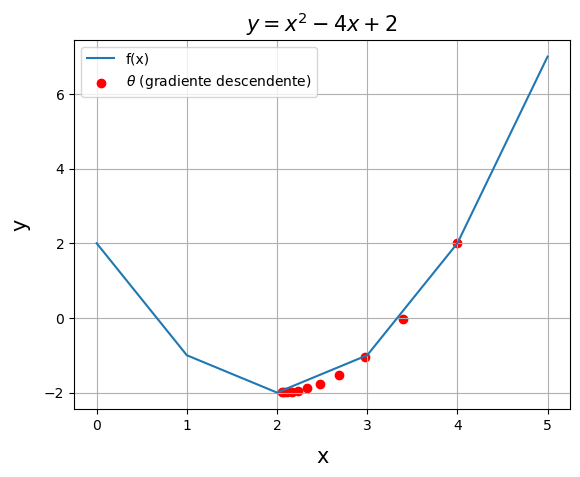

In [7]:
#fig = plt.figure(figsize=(7,7))

plt.plot(func_y(np.arange(6)), label="f(x)")
plt.scatter(xgd,ygd, color="red", label=r"$\theta$ (gradiente descendente)")
plt.title("$y = x^{2} - 4x + 2$", fontweight="bold", size=15)
plt.xlabel("x", labelpad=10, size="15")
plt.ylabel("y", labelpad=10, size="15")
plt.legend()
plt.grid()

plt.show()

O uso do método do gradiente descendente neste exemplo parece trivial, pois nossa função é bem comportada. Apesar disso, com funções mais complexas - como a mostrada a seguir, encontrar o valor mínimo pode ser difícil e é por isso que utilizamos este método.

O objetivo não é testar o método com muitos exemplos complexos, mas apenas mostrar como começar a pensar na solução de problemas mais complicados.

### Encontrando o Mínimo de uma Função mais Complicada

E se quisermos fazer a mesma coisa para estimar dois parâmetros ao invés de um?

Vamos usar a função abaixo como exemplo e ver se conseguimos encontrar o seu mínimo usando o Método do Gradiente Descendente.

Iremos fazer os mesmos procedimentos anteriores, calculando a função custo para cada parâmetro (ou variável) que iremos estimar, sendo $x$ e $y$; ajustaremos o valor de $\alpha$ (a nossa taxa de atualização) e vamos executar o algorítmo do gradiante descendente. Mas desta vez, $\theta_{x}$ e $\theta_{y}$ serão atualizados simultaneamente enquando o gradiente desce, ao invés de um único valor de $\theta$:

\begin{align}
z = f(x,y) &= 4x^2 + 2y^2 - 2xy \\
\frac{dz}{dx} &= 8x - 2y \\
\frac{dz}{dy} &= 4y - 2x
\end{align}

com,

* $\theta_{i} := \theta_{i-1} - \alpha \frac{dz}{d\theta_{i-1}}$, ou seja, por definição estabelecemos que $\theta_{i}$ é o valor de $\theta$ do passo anterior (para $i=1$, $\theta_{i-1}$ é o chute inicial) subtraído da derivada da função com relação à $\theta$, ponderado por $\alpha$ (que dirá para $\theta$ para qual direção ir).

Com esta função, sabemos que o seu mínimo real está em $(0,0)$, então o resultado da aplicação do algorítmo deverá ser fácil de verificar.

In [8]:
# A função abaixo, calcula o valor de f(x,y)
def func_z(x,y):
    return 4*x**2 + 2*y**2 - 2*x*y

# A função a seguir, calcula o valor da derivada de z em função de x
def dx(x,y):
    return 8*x - 2*y

# Cálculo da derivada de z em função de y
def dy(x,y):
    return 4*y - 2*x

# Função principal 
def gradient_descent_xy(theta_x,theta_y,alpha,epoch):
    
    # Inicializa as listas com os valores das derivadas
    grad_x = [] 
    grad_y = []

    # Adiciona os valores iniciais de teta_0 a x e teta_1 a y
    grad_x.append(theta_x)
    grad_y.append(theta_y)

    # Executa o método do gradiente descendente 
    # para cada passo de tempo (epoch)
    for i in range(epoch):
        current_theta_x = theta_x - alpha * dx(theta_x,theta_y)
        current_theta_y = theta_y - alpha * dy(theta_x,theta_y)
        grad_x.append(current_theta_x)
        grad_y.append(current_theta_y)

        # Atualiza os valores de teta_0 (x) e teta_1 (y)
        theta_x = current_theta_x
        theta_y = current_theta_y
    
    # Finaliza a função principal e retorna os valores
    # atualizados de teta_0 (x), teta_1 (y) e os gradientes nas
    # direções x e y
    return theta_x, theta_y, grad_x, grad_y

In [9]:
# Valores iniciais a serem utilizando na minimização

# Chutes iniciais para teta_0 (x) e teta_1 (y)
theta_x = 30
theta_y = 40

# Valor inicial para alfa
alpha = 0.05
    
# Número de iterações
epoch = 100

gd2 = gradient_descent_xy(theta_x,theta_y,alpha,epoch)

In [10]:
gd2

(5.879740666212515e-07,
 1.4194949659606872e-06,
 [30,
  22.0,
  16.7,
  13.04,
  10.407,
  8.440999999999999,
  6.9261099999999995,
  5.729284,
  4.7657259,
  3.9792527799999995,
  3.3310627189999993,
  2.7932389999999994,
  2.3449351220699994,
  1.9700868408979995,
  1.6560020698842997,
  1.3924620826159597,
  1.1711259428167227,
  0.9851191411139107,
  0.8287376044356154,
  0.6972266498863234,
  0.5866106357561136,
  0.49355836461198704,
  0.41527471165140845,
  0.3494121649443379,
  0.2939979164459111,
  0.24737336550043673,
  0.2081436909710332,
  0.17513568557424122,
  0.1473624250475521,
  0.12399362284667957,
  0.1043307322130019,
  0.08778602236026327,
  0.07386498716425768,
  0.06215155152063702,
  0.05229562816169072,
  0.044002650211667604,
  0.03702476506034001,
  0.031153425484992243,
  0.026213156100629333,
  0.022056308562934713,
  0.01855864862081281,
  0.015615643044558621,
  0.013139335410600047,
  0.011055717343897514,
  0.009302516638474497,
  0.007827336142232464,

In [11]:
gd2[0]

5.879740666212515e-07

In [12]:
gd2[1]

1.4194949659606872e-06

In [13]:
gd2[2]

[30,
 22.0,
 16.7,
 13.04,
 10.407,
 8.440999999999999,
 6.9261099999999995,
 5.729284,
 4.7657259,
 3.9792527799999995,
 3.3310627189999993,
 2.7932389999999994,
 2.3449351220699994,
 1.9700868408979995,
 1.6560020698842997,
 1.3924620826159597,
 1.1711259428167227,
 0.9851191411139107,
 0.8287376044356154,
 0.6972266498863234,
 0.5866106357561136,
 0.49355836461198704,
 0.41527471165140845,
 0.3494121649443379,
 0.2939979164459111,
 0.24737336550043673,
 0.2081436909710332,
 0.17513568557424122,
 0.1473624250475521,
 0.12399362284667957,
 0.1043307322130019,
 0.08778602236026327,
 0.07386498716425768,
 0.06215155152063702,
 0.05229562816169072,
 0.044002650211667604,
 0.03702476506034001,
 0.031153425484992243,
 0.026213156100629333,
 0.022056308562934713,
 0.01855864862081281,
 0.015615643044558621,
 0.013139335410600047,
 0.011055717343897514,
 0.009302516638474497,
 0.007827336142232464,
 0.0065860877790424365,
 0.0055416749038101525,
 0.004662883609184269,
 0.003923449848067204,


In [14]:
gd2[3]

[40,
 35.0,
 30.2,
 25.83,
 21.967999999999996,
 18.615099999999998,
 15.736179999999997,
 13.281554999999997,
 11.198172399999997,
 9.435110509999998,
 7.946013685999998,
 6.689917220699998,
 5.631257676559999,
 4.739499653454999,
 3.988608406853799,
 3.3564869324714692,
 2.8244357542387712,
 2.3766611976726892,
 1.9998408722495424,
 1.6827464582431955,
 1.4159198315831887,
 1.1913969288421624,
 1.0024733795349285,
 0.8435061747930837,
 0.7097461563289007,
 0.5971967167077117,
 0.502494709916213,
 0.42281013703007375,
 0.35576167818148313,
 0.2993455850499417,
 0.2518758303246213,
 0.21193373748099723,
 0.17832559222082411,
 0.15004697249308507,
 0.12625273314653176,
 0.10623174933339448,
 0.08938566448788235,
 0.07521100809633988,
 0.06328414902557113,
 0.053248634830519836,
 0.04480453872070934,
 0.03769949583864875,
 0.03172116097537486,
 0.026690862321359893,
 0.022458261591477666,
 0.01889686093702958,
 0.01590022236384691,
 0.013378786668981771,
 0.011257196825566432,
 0.0094720

Nossos resultados são essencialmente $(0,0)$, o que nos diz que o algorítmo funcionou. O chute inicial dado $(30,40)$ estava distante do valor mínimo, mas a cada iteração (realizamos 100), os valores dos gradientes nas direções $x$ e $y$ convergiram para os valores corretos.

Assim, como para a estimação de um único parâmetro, vamos plotar os resultados e ver como o algorítmo desempenhou.

O gráfico a seguir, mostra a superfície da equação $z = 4x^2 + 2y^2 - 2xy$:

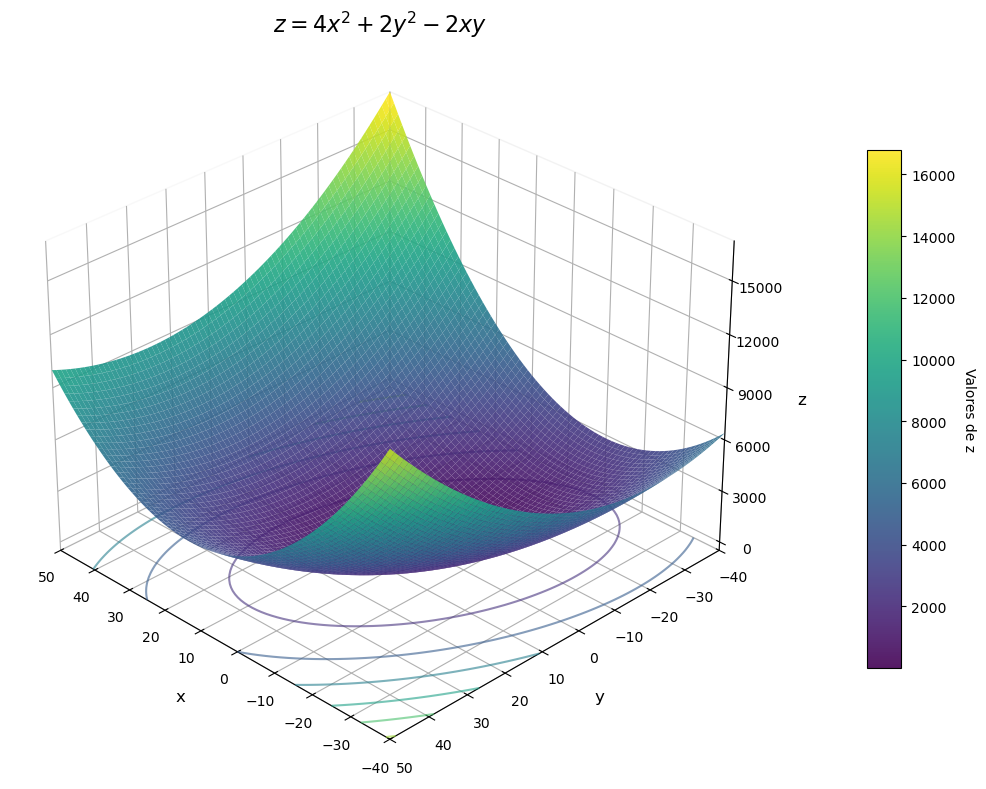

In [15]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.pyplot as plt

# Função exemplo
def func_z(x, y):
    return 4*x**2 + 2*y**2 - 2*x*y

# Dados
xvals = np.linspace(-40, 50, 80)
yvals = np.linspace(-40, 50, 80)
X, Y = np.meshgrid(xvals, yvals)
Z = func_z(X, Y)

# Figura
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Superfície suave
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    rstride=1, cstride=1,
    linewidth=0, antialiased=True,
    alpha=0.9
)

# Contornos projetados no "chão" (plano z mínimo)
ax.contour(X, Y, Z, zdir='z', offset=np.min(Z)-500, cmap=cm.viridis, alpha=0.6)

# Rótulos
ax.set_xlabel("x", labelpad=10, fontsize=12)
ax.set_ylabel("y", labelpad=10, fontsize=12)
ax.set_zlabel("z", labelpad=10, fontsize=12)
ax.set_title(r"$z = 4x^2 + 2y^2 - 2xy$", fontsize=16, fontweight="bold", pad=0)

# Limites e espaçamento
ax.set_xlim(-40, 50)
ax.set_ylim(-40, 50)
ax.set_zlim(np.min(Z)-500, np.max(Z))
ax.zaxis.set_major_locator(plt.MaxNLocator(6))

# Barras de cor e estilo
cbar = fig.colorbar(surf, shrink=0.7, aspect=15, pad=0.1)
cbar.set_label('Valores de z', rotation=270, labelpad=15)

# Ponto de vista e fundo
ax.view_init(elev=30, azim=135)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()


No gráfico a seguir podemos ver como se comporta o método do gradiente descendente na minimização das funções em $x$ e $y$, obtidas a partir da equação $z = 4x^2 + 2y^2 - 2xy$, no plano $xy$. Repare que neste plano também está destacado na figura anterior com as curvas de nível.

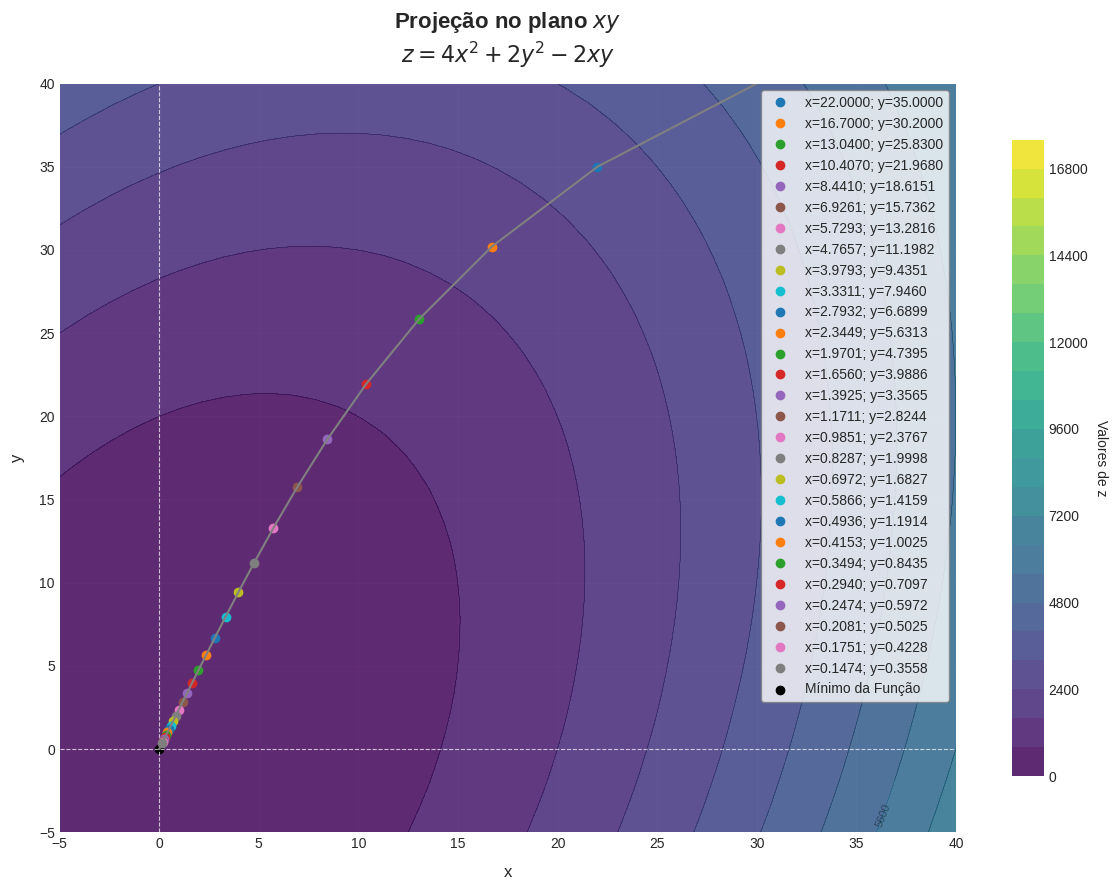

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Figura e eixo
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 9))

# Linhas-guia (eixos)
ax.axvline(0, linewidth=0.8, color="white", ls="--", alpha=0.7)
ax.axhline(0, linewidth=0.8, color="white", ls="--", alpha=0.7)

# Contornos com preenchimento
contour = ax.contourf(X, Y, Z, levels=25, cmap=cm.viridis, alpha=0.85)
contour_lines = ax.contour(X, Y, Z, levels=25, colors="black", linewidths=0.3, alpha=0.4)
plt.clabel(contour_lines, inline=True, fontsize=8, fmt="%.0f", colors="black")

for i in np.arange(1,len(gd2[2][1:30])):
    ax.plot(gd2[2][i],gd2[3][i], "o", label="x=%.4f; y=%.4f" %(gd2[2][i],gd2[3][i]))
    
#ax.plot(gd2[2][1:20], gd2[3][1:20], "-", color="grey")    
ax.plot(gd2[2], gd2[3], "-", color="grey")   
#ax.scatter(gd2[0], gd2[1], color="black", label="Mínimo da Função")
ax.scatter(0, 0, color="black", label="Mínimo da Função")

# Estilo e rótulos
ax.set_title("Projeção no plano $xy$\n$z = 4x^2 + 2y^2 - 2xy$", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("x", fontsize=12, labelpad=10)
ax.set_ylabel("y", fontsize=12, labelpad=10)
ax.set_xlim(-5, 40)
ax.set_ylim(-5, 40)
ax.legend(frameon=True, facecolor="white", edgecolor="gray", fontsize=10)

# Barra de cores
cbar = fig.colorbar(contour, ax=ax, shrink=0.85, pad=0.05)
cbar.set_label("Valores de z", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


## Exercícios

__No exemplo com a função quadrática em x, atribua diferentes valores de $\alpha$ (learning_rate) entre 1% e 100%.__

1. O que acontece com a convergência do método do gradiente descendente quando se utiliza diferentes valores de $\alpha$?
2. Existe um valor de $\alpha$ ótimo (ie., com o qual o método funciona melhor)?
3. Em quantas iterações o método converge para o valor mínimo da função (altere o valor da variável `epoch`)?

__No exemplo com a função quadrática a duas variáveis:__

1. Sabendo que o valor mínimo da função está na coordenada $(0,0)$, altere o chute inicial (parâmetros `theta_x` e `theta_y`) e verifique a convergência do método.
2. O que acontece com a convergência do método quando se utiliza diferentes valores de $\alpha$?
3. Quantas iterações são necessárias para a convergência do método em cada caso testado?

## Referências

* https://medium.com/@rrfd/what-is-a-cost-function-gradient-descent-examples-with-python-16273460d634